# Lesson 02b: Spherical Harmonics and the Equivariant Embedding of a Direction

**What you will learn**

- What the spherical harmonics $Y^{(l)}: S^2 \to \mathbb{R}^{2l+1}$ are, and the equivariance property $Y^{(l)}(R\hat r) = D^{(l)}(R)\, Y^{(l)}(\hat r)$ that enables them to turn a direction into effective typed features.
- Spherical harmonics follow the parity relation, $Y^{(l)}(-\hat r) = (-1)^l\, Y^{(l)}(\hat r)$. Thus, as $O(3)$ types, they are labeled using $(l, p)$ as `0e`, `1o`, `2e`, `3o`, ..., with parity $p = (-1)^l$.
- The `o3.spherical_harmonics` API, the `normalize` flag and the three `normalization` conventions (`'integral'`, `'component'`, `'norm'`), each with its defining equation and a numerical check.
- Visualization of the classic "orbital" pictures with radius and color denoting $|Y|$ and sign, respectively.
- How to expand a function on the sphere in the spherical-harmonic basis, and why truncating at $L$ is a low-pass filter. This is a prelude to the "angular features" of atomic environments which we will start using from Lesson 06a onward.

**Prerequisites:**

- [Lesson 01b](01b_group_representations.ipynb) and [Lesson 02a](02a_irreps_in_e3nn.ipynb), or
- Basic knowledge of e3nn's `o3.Irreps`, `D_from_matrix`, and
- Familiarity with Wigner D-matrices and irreps $(l,p)$ of $O(3)$.

In [1]:
import sys; sys.path.insert(0, "..")  # make course_utils importable

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3

from course_utils.equivariance import assert_model_equivariant, model_equivariance_error
from course_utils.plotting import (plot_spherical_harmonic,
                                   plot_spherical_harmonics_table, spherical_surface,
                                    scene3d, draw_spherical_harmonic,
                                    draw_sphere_field, show3d)

torch.set_default_dtype(torch.float64)  # equivariance checks at ~1e-15, not 1e-6
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## Definition: a direction in, one vector per $l$ out

Lesson 02a gave us the *type system*, in which features are declared as irreps $(l, p)$. But where do features with $l > 0$ come from in the first place? In atomistic models, the raw geometric input can involve a collection of **directions** (unit vectors $\hat r \in S^2$, e.g. from an atom to its neighbor). These directions can be transformed into features with various degrees $l$ by using spherical harmonics as a canonical method of embedding.

The spherical harmonics, $Y^{(l)}$, are a family of functions from the unit sphere to (the vector space carrying) the irrep $D^{(l)}$. For each $l = 0, 1, 2, \dots$ spherical hormonics form a vector of $2l+1$ functions $Y^{(l)}(\hat r) = \big(Y^{(l)}_{-l}(\hat r),\, Y^{(l)}_{-l+1}(\hat r),\, \dots,\, Y^{(l)}_{l}(\hat r)\big)$, and each $Y^{(l)}$ is **equivariant**:

$$ Y^l_m(R\vec x) \;=\; \sum_{n=-l}^{l} D^l(R)_{mn}\, Y^l_n(\vec x), $$

where $\vec x$ is a unit direction $\hat r$, $R$ is a rotation matrix and $D^l$ is an irreducible representation of $SO(3)$. In matrix form, with $D^{(l)}(R)$ the $(2l+1)\times(2l+1)$ Wigner D-matrix from Lesson 01b:

$$ Y^{(l)}(R\,\hat r) \;=\; D^{(l)}(R)\; Y^{(l)}(\hat r). $$

Read it as: *rotate the input direction, and the $2l+1$ output numbers rotate along with the matching Wigner matrix*. Two special cases anchor the intuition: $Y^{(0)}$ is a constant (a rotation-invariant scalar), and $Y^{(1)}(\hat r) \propto \hat r$ is the direction itself. Spherical harmonics, which are a basis for all equivariant polynomials on a sphere, will have higher oscillation frequencies on the sphere as their $l$ values increase.

In e3nn, `o3.Irreps.spherical_harmonics(l_max)` builds the output type $\bigoplus_{l=0}^{l_\text{max}} (l, (-1)^l)$, and `o3.spherical_harmonics` evaluates it.

In [2]:
# irreps of (l, (-1)^l) for l = 0, 1, 2, 3
l_max = 3
sh_irreps = o3.Irreps.spherical_harmonics(l_max)
print(f"sh_irreps = {sh_irreps}   (dim = {sh_irreps.dim} = 1 + 3 + 5 + 7)\n")

# One unit direction (batch of 1)
rhat = torch.tensor([[0.0, 0.6, 0.8]])
Y = o3.spherical_harmonics(sh_irreps, rhat, normalize=True, normalization="component")

# Print the spherical harmonics for each irreducible representation
for mul_ir, sl in zip(sh_irreps, sh_irreps.slices()):
    print(f"  Y^({mul_ir.ir.l}) as {mul_ir.ir}:  {np.round(Y[0, sl].numpy(), 3)}")

# Print the direction rhat itself, which is proportional to Y^(1)
print(f"\nY^(1)/sqrt(3) = {np.round((Y[0, 1:4] / 3**0.5).numpy(), 3)}"
      f"   <- the direction rhat itself")

sh_irreps = 1x0e+1x1o+1x2e+1x3o   (dim = 16 = 1 + 3 + 5 + 7)



  Y^(0) as 0e:  [1.]
  Y^(1) as 1o:  [0.    1.039 1.386]
  Y^(2) as 2e:  [0.    0.    0.089 1.859 1.239]
  Y^(3) as 3o:  [ 0.     0.     0.    -0.952  1.037  1.967  1.071]

Y^(1)/sqrt(3) = [0.  0.6 0.8]   <- the direction rhat itself


## Parity: why the types are `0e`, `1o`, `2e`, `3o`, …

Eq. (1) covers rotations. For the full $O(3)$ we also need the inversion $P: \hat r \mapsto -\hat r$. Extended from $S^2$ to $\mathbb{R}^3$, the spherical harmonics can be chosen to be polynomials of $\vec x$: homogeneous polynomials of degree $l$ (e.g. $Y^{(2)}$ to $x^2, xy, \dots$). Substituting $\hat r \to -\hat r$ flips the sign of each of the $l$ factors:

$$ Y^{(l)}(-\hat r) \;=\; (-1)^l\, Y^{(l)}(\hat r). $$

So, $Y^{(l)}$ transforms as the irrep $(l,\, p)$ with parity $p = (-1)^l$:

| $l$ | 0 | 1 | 2 | 3 | $\cdots$ |
|---|---|---|---|---|---|
| type of $Y^{(l)}$ | `0e` (scalar) | `1o` (vector) | `2e` | `3o` | $(l, (-1)^l)$ |

These are exactly the labels `o3.Irreps.spherical_harmonics` produced above. Combining both statements, for **any** $g \in O(3)$ (rotation or improper rotation):

$$ Y^{(l)}(g\,\hat r) \;=\; D^{(l,p)}(g)\; Y^{(l)}(\hat r), $$

where $p = (-1)^l$, and $D^{(l,p)}$ is the $O(3)$ irrep matrix from Lesson 02a (`o3.Irrep(l, p).D_from_matrix`).

Let's check the parity claim numerically for each $l$:

In [3]:
# Create 8 unit random direction vectors
rhat = torch.nn.functional.normalize(torch.randn(8, 3), dim=-1)

# Check the parity property of spherical harmonics: Y^(l)(-rhat) = (-1)^l * Y^(l)(rhat)
for l in range(l_max + 1):
    # Y^(l)(+rhat)
    Y_plus = o3.spherical_harmonics(l, rhat, normalize=True)
    # Y^(l)(-rhat)
    Y_minus = o3.spherical_harmonics(l, -rhat, normalize=True)
    p = (-1) ** l
    err = (Y_minus - p * Y_plus).abs().max().item()
    print(f"l={l}:  max |Y(-r) - ({p:+d})*Y(r)| = {err:.1e}   ->  type {o3.Irrep(l, p)}")

l=0:  max |Y(-r) - (+1)*Y(r)| = 0.0e+00   ->  type 0e
l=1:  max |Y(-r) - (-1)*Y(r)| = 0.0e+00   ->  type 1o
l=2:  max |Y(-r) - (+1)*Y(r)| = 0.0e+00   ->  type 2e
l=3:  max |Y(-r) - (-1)*Y(r)| = 0.0e+00   ->  type 3o


## The `o3.spherical_harmonics()` API

In the `o3.spherical_harmonics(l, x, normalize, normalization)` function signature, `l` may be a single degree, a list of degrees, or an `Irreps` like `sh_irreps` (outputs are concatenated along the last axis in the order given). The two remaining arguments select *what function* is evaluated and *how it is scaled*.

### `normalize`: what happens to the length of `x`

The harmonics are defined on the unit sphere, but can be extended to $\mathbb{R}^3$ as homogeneous polynomials of degree $l$. For an arbitrary (non-unit) input $\vec x$, the `normalize` flag picks between the two readings:

- **`normalize=True`**: evaluate on the projected direction, $\;Y^{(l)}\!\big(\vec x / \lVert\vec x\rVert\big)$: here, the output depends on the direction only. This is what we want for *direction embeddings*.
- **`normalize=False`**: evaluate the polynomial on $\mathbb{R}^3$. Homogeneity means

$$ Y^{(l)}(\lambda \vec x) = \lambda^l\, Y^{(l)}(\vec x) \qquad (\lambda > 0). $$

Thus, the output magnitude grows like $\lVert\vec x\rVert^l$. This can be useful when a smooth polynomial in $\vec x$, which is finite at $\vec x = 0$, is needed, e.g., inside some tensor field constructions.

In [4]:
# Generic, non-unit inputs
x = torch.randn(4, 3)

# Loop over l = 1, 2, 3 to check the homogeneity property of spherical harmonics
for l in [1, 2, 3]:
    Y_poly = lambda v: o3.spherical_harmonics(l, v, normalize=False)
    # Should be 2**l
    scale = (Y_poly(2 * x) / Y_poly(x)).mean().item()
    # normalize = True ...
    Y_dir = o3.spherical_harmonics(l, x, normalize=True)
    # ... == Y(x/|x|)
    Y_manual = Y_poly(x / x.norm(dim=-1, keepdim=True))
    err = (Y_dir - Y_manual).abs().max().item()
    print(f"l={l}:  Y(2x)/Y(x) = {scale:4.1f} = 2^{l}   |   "
          f"max |Y_dir - Y(x/|x|)| = {err:.1e}")

l=1:  Y(2x)/Y(x) =  2.0 = 2^1   |   max |Y_dir - Y(x/|x|)| = 0.0e+00
l=2:  Y(2x)/Y(x) =  4.0 = 2^2   |   max |Y_dir - Y(x/|x|)| = 0.0e+00
l=3:  Y(2x)/Y(x) =  8.0 = 2^3   |   max |Y_dir - Y(x/|x|)| = 0.0e+00


### `normalization`: the overall scale of $Y^{(l)}$

The norm $\lVert Y^{(l)}(\hat r)\rVert$ is rotation-invariant (Wigner matrices are orthogonal), and any two points in $S^2$ are related by a rotation. Therefore, the norm is a single **constant per $l$**, evaluated anywhere on the sphere. The three normalization conventions, available in e3nn, differ only in that constant. With $d\Omega$ representing the surface element of $S^2$ (with total area of $4\pi$):

| `normalization` | defining property | $\lVert Y^{(l)}(\hat r)\rVert$ on the sphere |
|---|---|---|
| `'norm'` | $\lVert Y^{(l)}(\hat r)\rVert = 1$ | $1$ |
| `'component'` | each component has unit mean square: $\frac{1}{4\pi}\int_{S^2} \big(Y^{(l)}_m\big)^2\, d\Omega = 1$ | $\sqrt{2l+1}$ |
| `'integral'` | orthonormal in $L^2(S^2)$: $\int_{S^2} Y^{(l)}_m(\hat r)\, Y^{(l')}_{m'}(\hat r)\, d\Omega = \delta_{ll'}\delta_{mm'}$ | $\sqrt{\tfrac{2l+1}{4\pi}}$ |

- `'norm'` corresponds to the $\lVert Y^l(\vec x)\rVert = 1$ convention (see [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453) for further details).
- `'component'` gives every *component* a unit variance over the directions. This is the convention that keeps the signals well-scaled inside networks. Also, this is the e3nn **default** option for normalization.
- `'integral'` makes the functions orthonormal for the scalar product $\langle f, g\rangle = \int_{S^2} f(\vec x) g(\vec x)\, d\vec x$. The is the physics/math literature convention.

The last-column values follow from the constancy of the norm: e.g. for `'integral'`, summing the defining property over $m$ gives $\int_{S^2} \lVert Y^{(l)}\rVert^2 d\Omega = 2l+1$, and a constant integrand means $4\pi \lVert Y^{(l)}\rVert^2 = 2l+1$. The three conventions are proportional:

$$ Y^{(l)}_{\text{component}} = \sqrt{4\pi}\; Y^{(l)}_{\text{integral}}, \qquad \text{and} \qquad Y^{(l)}_{\text{norm}} = \frac{1}{\sqrt{2l+1}}\; Y^{(l)}_{\text{component}}. $$

Let's numerically check the aforementioned normalization conventions for a few $l$ values

In [5]:
# Create a single random unit direction vector
rhat = torch.nn.functional.normalize(torch.randn(6, 3), dim=-1)

# Tabulate the expected norms of spherical harmonics for each normalization convention
expected = {"integral": "sqrt((2l+1)/4pi)", "component": "sqrt(2l+1)", "norm": "1"}

# Print the norms of spherical harmonics for each normalization convention
print(f"||Y^(l)(rhat)||  {'l=0':>6}{'l=1':>8}{'l=2':>8}{'l=3':>8}    defining constant")
for conv, formula in expected.items():
    norms = [o3.spherical_harmonics(l, rhat, normalize=True, normalization=conv)
             .norm(dim=-1).mean().item() for l in range(l_max + 1)]
    print(f"{conv:<15}" + "".join(f"{n:>8.4f}" for n in norms) + f"    {formula}")

vals = [np.sqrt((2 * l + 1) / (4 * np.pi)) for l in range(l_max + 1)]
print(f"{'':15}" + "".join(f"{v:>8.4f}" for v in vals) + "    <- sqrt((2l+1)/4pi)")

||Y^(l)(rhat)||     l=0     l=1     l=2     l=3    defining constant
integral         0.2821  0.4886  0.6308  0.7464    sqrt((2l+1)/4pi)
component        1.0000  1.7321  2.2361  2.6458    sqrt(2l+1)
norm             1.0000  1.0000  1.0000  1.0000    1
                 0.2821  0.4886  0.6308  0.7464    <- sqrt((2l+1)/4pi)


To check the *integral* statements, instead of just pointwise norms, we need quadrature on the sphere. A Gauss–Legendre grid in $\cos\theta$ times a uniform grid in $\phi$ integrates $\int_{S^2} h\, d\Omega = \int_0^{2\pi}\!\!\int_{-1}^{1} h \; d(\cos\theta)\, d\phi$ **exactly** for polynomials of the degrees involved here. As such, the orthonormality  relation,

$$
\int_{S^2} Y^{(l)}_m(\hat r)\, Y^{(l')}_{m'}(\hat r)\, d\Omega = \delta_{ll'}\delta_{mm'}
$$

comes out at machine precision. Let us define a helper function to generate the quadrature grid and weights using Numpy

In [6]:
def sphere_quadrature(n_theta=20, n_phi=41):
    """Nodes rhat_k (K, 3) and weights w_k with sum_k w_k h(rhat_k) = int_{S^2} h dOmega
    (exact for polynomials in rhat up to degree ~ 2*n_theta - 1)."""
    # Gauss-Legendre in cos(theta)
    ct, w_gl = np.polynomial.legendre.leggauss(n_theta)
    # Uniform grid in phi (trapezoid)
    phi = np.arange(n_phi) * 2 * np.pi / n_phi
    # Compute sin(theta) from cos(theta)
    st = np.sqrt(1.0 - ct**2)
    # Stack the points in spherical coordinates and reshape to (K, 3)
    pts = np.stack([np.outer(st, np.cos(phi)), np.outer(st, np.sin(phi)),
                    np.outer(ct, np.ones(n_phi))], axis=-1).reshape(-1, 3)
    # The weights are the product of the Gauss-Legendre weights and the uniform phi weights
    w = np.outer(w_gl, np.full(n_phi, 2 * np.pi / n_phi)).ravel()
    return torch.from_numpy(pts), torch.from_numpy(w)

# Create quadrature points and weights for numerical integration over the sphere
pts, w = sphere_quadrature()

# Create the identity matrix for comparison
Id = torch.eye(sh_irreps.dim)

# Compute the Gram matrix for the 'integral' normalization
Y_int = o3.spherical_harmonics(sh_irreps, pts, normalize=True, normalization="integral")
gram = (Y_int * w[:, None]).T @ Y_int                     # gram_ij = int Y_i Y_j dOmega
print(f"'integral' :  max |gram - I|      = {(gram - Id).abs().max():.2e}")

# Compute the Gram matrix for the 'component' normalization 
Y_cmp = o3.spherical_harmonics(sh_irreps, pts, normalize=True, normalization="component")
gram = (Y_cmp * w[:, None]).T @ Y_cmp
print(f"'component':  max |gram/4pi - I|  = {(gram / (4 * np.pi) - Id).abs().max():.2e}")

'integral' :  max |gram - I|      = 6.91e-15
'component':  max |gram/4pi - I|  = 7.01e-15


## Visualization of the spherical harmonics

A classic way to draw a function $S^2 \to \mathbb{R}$ is to place the surface point, belonging to direction $\hat r$, at **radius $|Y^{(l)}_m(\hat r)|$** and **color it by the sign** of $Y^{(l)}_m(\hat r)$ (here, red $= +$, blue $= -$, white $\approx 0$). The big lobes are where the function is large in magnitude. Also, the surface pinches to the origin on the *nodal lines* where it changes sign. Our helper `course_utils.plotting.plot_spherical_harmonic` does exactly this.

In the table below (rows $l = 0, ..., 3$, columns $m = -l, ..., l$), notice:

- row $l$ has $2l+1$ members: one full set of irreps. A rotation *mixes the members of a row* into each other (Eq. (1)) but never mixes different rows.
- The number of nodes grows with $l$: higher $l$ gives higher angular frequency, the "Fourier modes of the sphere" from section 1.

An important point is that the harmonics depend heavily on the choice of basis of the irreducible representation. As e3nn's real basis orders the $l = 1$ components as $(x, y, z)$, i.e., $m = -1, 0, +1$ correspond to $x, y, z$, respectively, the $Y_1^{0}$ below points along $y$, unlike the textbook $p_z$. There's nothing of scientific significance here, just a basis choice.

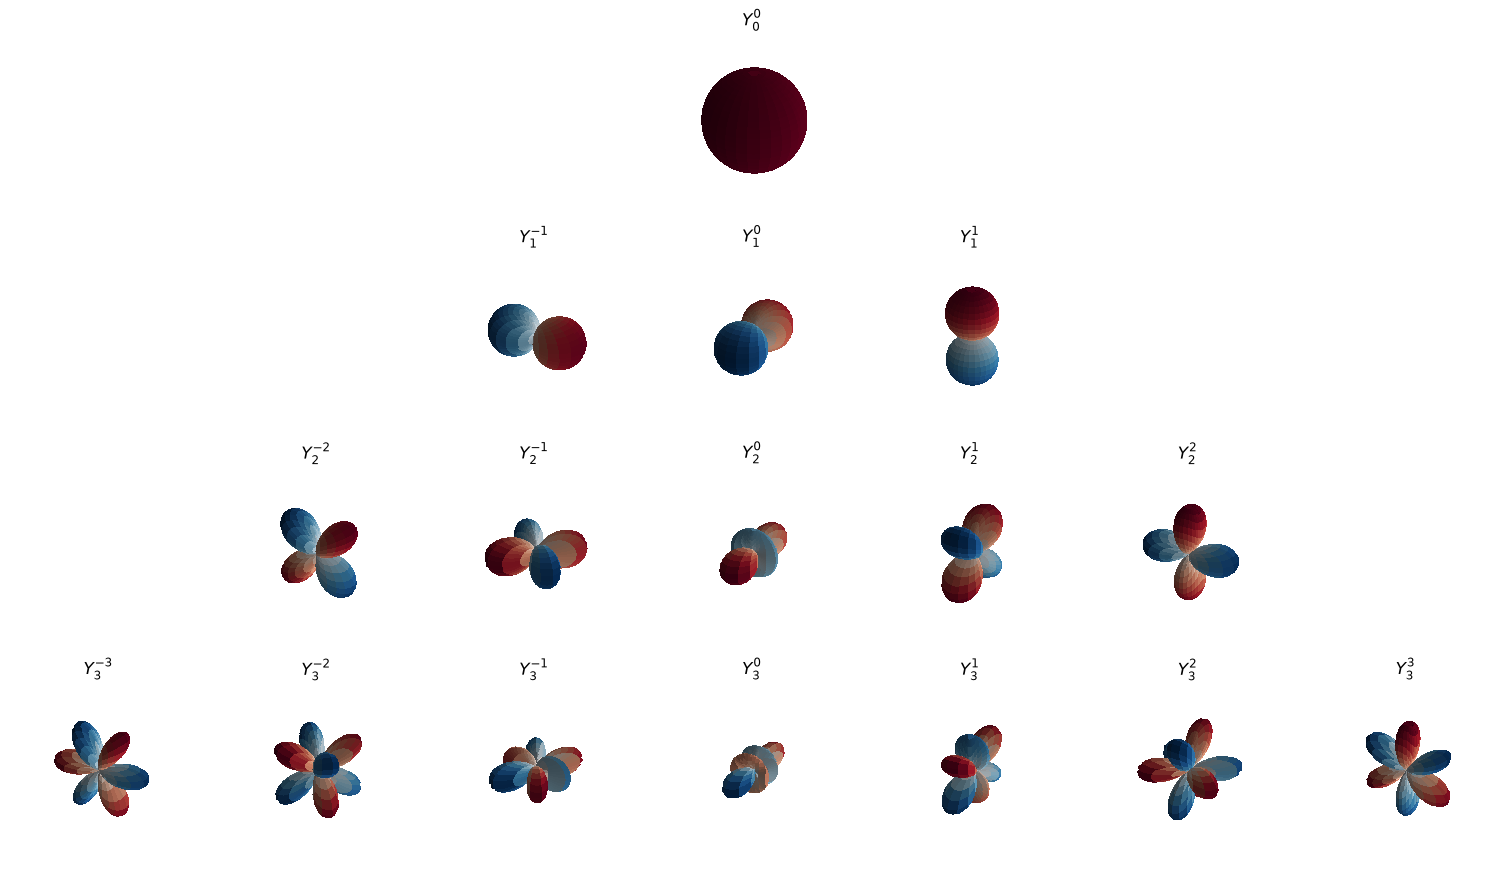

In [7]:
# Rows: l = 0, ..., 3,
# Columns: m = -l, ..., l
fig = plot_spherical_harmonics_table(l_max=3)

For more clarity, let's take a closer look at two of the harmonics, $Y_1^0$ and $Y_3^2$ below.

In [8]:
# Two close-ups -- drag to rotate, scroll to zoom
fig = scene3d(1, 2, titles=["Y(l=1, m=0)", "Y(l=3, m=2)"])

# Y_1^0: one nodal plane -> two lobes (a p-orbital picture; along y
# in e3nn's basis).
draw_spherical_harmonic(1, 0, fig=fig, cell=(1, 1), n=60)

# Y_3^2: degree 3, more sign changes -> more, smaller lobes.
draw_spherical_harmonic(3, 2, fig=fig, cell=(1, 2), n=60)
show3d(fig, legend=False)

The first, $Y_1^0$, has one nodal plane and two lobes (a "p-orbital" picture; along $y$ in e3nn's basis). The second, $Y_3^2$, has degree 3, more sign changes, and thus more, smaller lobes.

## Verifying the equivariance

First, let us numerically check the $Y^{(l)}(g\hat r) = D^{(l,p)}(g)\, Y^{(l)}(\hat r)$. Our directions are stored as **rows** of a `(N, 3)` tensor, so each side maps to code as:

| math | code | why |
|---|---|---|
| $g\,\hat r$ (column convention) | `pts @ g.T` | $(g\hat r)^\top = \hat r^\top g^\top$, row-wise |
| $D^{(l,p)}(g)$ | `o3.Irrep(l, p).D_from_matrix(g)` | Wigner matrix of the $O(3)$ irrep (Lesson 02a) |
| LHS $\;Y^{(l)}(g\hat r)$ | `sh(l, pts @ g.T)` | transform *then* embed |
| RHS $\;D^{(l,p)}(g)\,Y^{(l)}(\hat r)$ | `sh(l, pts) @ D.T` | embed *then* transform |

We test a proper rotation ($\det g = +1$) against Eq. (1), and an **improper** element $g = -R$ ($\det g = -1$: inversion composed with a rotation) which additionally exercises the parity $p = (-1)^l$ from §2. The `D_from_matrix` accepts any orthogonal matrix and applies the parity factor automatically.

In [9]:
# Proper rotation, det = +1
R = o3.rand_matrix()

# improper: inversion o rotation, det = -1
g_imp = -o3.rand_matrix()

# Create 16 random unit direction vectors
pts = torch.nn.functional.normalize(torch.randn(16, 3), dim=-1)

# Check the equivariance property of spherical harmonics for both proper and improper rotations
for l, g, name in [(2, R, "proper rotation R "), (3, g_imp, "improper g = -R   ")]:
    # the type of Y^(l), cf. section 2
    ir = o3.Irrep(l, (-1) ** l)
    # D^{(l,p)}(g), (2l+1) x (2l+1)
    D = ir.D_from_matrix(g)
    # Compute the left-hand side and right-hand side of the equivariance property
    # Y^(l)(g rhat)
    lhs = o3.spherical_harmonics(l, pts @ g.T, normalize=True)
    # D^{(l,p)}(g) Y^(l)
    rhs = o3.spherical_harmonics(l, pts, normalize=True) @ D.T
    print(f"{name} l={l} ({ir}):  max |LHS - RHS| = {(lhs - rhs).abs().max():.2e}")

proper rotation R  l=2 (2e):  max |LHS - RHS| = 2.22e-15
improper g = -R    l=3 (3o):  max |LHS - RHS| = 1.58e-15


Now the whole embedding $\;\hat r \mapsto \big(Y^{(0)} \,\|\, Y^{(1)} \,\|\, Y^{(2)} \,\|\, Y^{(3)}\big)$, treated as a model `positions -> features` of output type `sh_irreps`, goes through the standard course harness (`course_utils.equivariance.assert_model_equivariant`) for checking its equivariance property. As in Lesson 02a, the harness draws random $O(3)$ elements, half of them improper, so a wrong parity labels would be caught.

Here, we deliberately adopted the flag **`translation=False`**. This is because the mapping, $\vec r \mapsto Y^{(l)}(\hat r)$, uses the direction of an *absolute position*, which changes when the whole system is shifted: no useful feature can be translation-equivariant using that input. In Part II, we develop networks in which, we apply an embedding to **relative** vectors $\vec r_{ij} = \vec r_j - \vec r_i$ (sign convention: pointing from $i$ to $j$), which remain unchanged by translations. This is how full $E(3)$ symmetry is restored (Lessons 05a and 06a).

In [10]:
# Feature embedding function that maps 3D positions to spherical harmonic features
def sh_embed(pos):
    """Direction embedding: (N, 3) positions -> (N, 16) features of type sh_irreps."""
    return o3.spherical_harmonics(sh_irreps, pos, normalize=True,
                                  normalization="component")

# Create a batch of 32 random 3D positions
pos = torch.randn(32, 3)
print(f"O(3), rotations + parity, no translations:", end="  ")

# Check the equivariance of the embedding function with respect to rotations and
# parity (no translations)
assert_model_equivariant(sh_embed, pos, sh_irreps, translation=False)

# Check the equivariance of the embedding function with random translations
err_t = model_equivariance_error(sh_embed, pos, sh_irreps, translation=True)
print(f"with random translations:  max error = {err_t:.2f}  -> NOT equivariant!"
      f"\nFix: embed relative vectors r_ij = r_j - r_i  (Lessons 05a, 06a)")

O(3), rotations + parity, no translations:  equivariant!  (max error 1.582e-14 over random O(3) elements)
with random translations:  max error = 3.90  -> NOT equivariant!
Fix: embed relative vectors r_ij = r_j - r_i  (Lessons 05a, 06a)


## Functions on the sphere: lists of irrep coefficients

The spherical harmonics are not only an embedding for directions, but also a **basis** for functions on the sphere, i.e., $f: \mathbb{S}^2 \to \mathbb{R}$

$$ f(\vec x) = \sum_{l=0}^{\infty} v^l \cdot Y^l(\vec x), $$

where $v^l \in \mathbb{R}^{2l+1}$ are the coefficients of the function expansion. With the ``integral`` normalization, the basis is orthonormal and the coefficients are plain projections:

$$ v^{(l)}_m \;=\; \int_{S^2} f(\hat r)\, Y^{(l)}_m(\hat r)\; d\Omega. $$

Two facts make spherical harmonics a popular representation of angular information in equivariant networks:

1. **The coefficients transform as irreps:** Rotating the function, $[Rf](\vec x) = f(R^{-1}\vec x)$, maps $v^l \mapsto D^l(R)\, v^l$. A function on the sphere is (equivariantly) a list of irreps $0 \oplus 1 \oplus 2 \oplus \dots$ .
2. **Truncation is a low-pass filter.** Truncating the coefficients to a maximum $L$ cuts off the high frequencies of the signal. As such, finite feature vectors imply finite angular resolution.

As a test signal, we take something shaped like what an atom "sees": a smooth bump at each of three "neighbor" directions $\hat n_j$,

$$ f(\hat r) \;=\; \sum_{j=1}^{3} e^{\beta\,(\hat r \cdot \hat n_j \,-\, 1)}, \qquad \beta = 8, $$

where $\beta$ sets the sharpness of the bumps (larger $\beta$ $\Rightarrow$ sharper peaks $\Rightarrow$ higher-$l$ content).

In [11]:
# Control sharpness
beta = 8.0

# Define three "neighbor" directions and normalize them to unit vectors
n_hat = torch.nn.functional.normalize(torch.tensor(
    [[1.0, -0.4, 0.4], [-0.4, -1.0, 0.6], [0.6, 0.4, 1.0]]), dim=-1)

# Define a signal function on the sphere that has bumps in the directions of n_hat
def f_signal(rhat):
    # (K, 3) unit vectors -> (K,) signal values
    return torch.exp(beta * (rhat @ n_hat.T - 1.0)).sum(-1)

# Set the maximum degree of spherical harmonics to compute
L_max = 10
irreps_L = o3.Irreps.spherical_harmonics(L_max)

# Create quadrature points and weights for numerical integration over the sphere 
pts, w = sphere_quadrature(n_theta=40, n_phi=81)

# Compute the spherical harmonics for the quadrature points
Y = o3.spherical_harmonics(irreps_L, pts, normalize=True, normalization="integral")

# v^l_m = int f(rhat) Y^l_m(rhat) dOmega
v = (w * f_signal(pts)) @ Y

# Compute the norms of the coefficients for each degree l
norms = [v[sl].norm().item() for _, sl in zip(irreps_L, irreps_L.slices())]
print("coefficient norms ||v^(l)||  (smooth signal -> fast decay with l):")

# Print the norms of the coefficients for each degree l, along with a visual representation
for l, n in enumerate(norms):
    print(f"  l={l:>2}:  {n:8.4f}  " + "#" * int(60 * n / max(norms)))

coefficient norms ||v^(l)||  (smooth signal -> fast decay with l):
  l= 0:    0.6647  ########################################################
  l= 1:    0.7101  ############################################################
  l= 2:    0.3559  ##############################
  l= 3:    0.3637  ##############################
  l= 4:    0.3394  ############################
  l= 5:    0.1930  ################
  l= 6:    0.0897  #######
  l= 7:    0.0481  ####
  l= 8:    0.0229  #
  l= 9:    0.0081  
  l=10:    0.0023  


Now, let us reconstruct the truncated series $f_L(\hat r) = \sum_{l \le L} v^{(l)} \cdot Y^{(l)}(\hat r)$ for increasing cutoff $L$ and measure the relative $L^2(S^2)$ error $\lVert f_L - f \rVert_{L^2} / \lVert f \rVert_{L^2}$ (computed on the same quadrature grid):

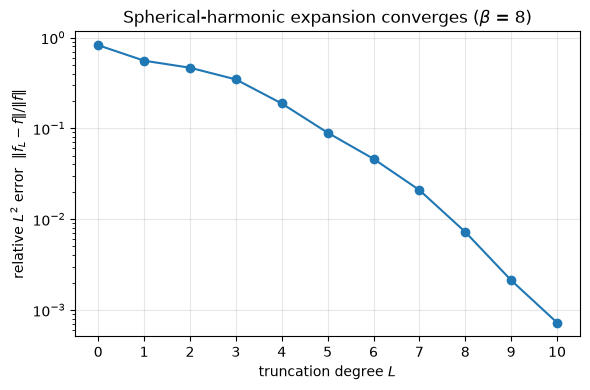

In [12]:
# Compute the true signal values at the quadrature points
f_true = f_signal(pts)

# Reconstruct the truncated series f_L(rhat) = sum_{l <= L} v^(l) . Y^(l)(rhat) for increasing cutoff L
# and measure the relative L^2(S^2) error ||f_L - f||
errors = []
for L in range(L_max + 1):
    # (L+1)^2 coefficients
    dim_L = o3.Irreps.spherical_harmonics(L).dim
    # f_L = sum_{l<=L} v^l . Y^l
    f_L = Y[:, :dim_L] @ v[:dim_L]
    rel = torch.sqrt((w * (f_L - f_true) ** 2).sum() / (w * f_true**2).sum())
    errors.append(rel.item())

# Plot the relative L^2 error as a function of truncation degree L
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(range(L_max + 1), errors, "o-", color="C0")
ax.set_xlabel(r"truncation degree $L$")
ax.set_ylabel(r"relative $L^2$ error  $\Vert f_L - f \Vert / \Vert f \Vert$")
ax.set_title(rf"Spherical-harmonic expansion converges ($\beta$ = {beta:.0f})")
ax.set_xticks(range(L_max + 1)); ax.grid(True, alpha=0.3)
fig.tight_layout()

The same convergence behavior is also seen on a sphere, with radius = |f_L| and color values based on the sign of f_L

In [13]:
# Set up a grid of points on the sphere for visualization
theta, phi, xyz = spherical_surface(80)

# Compute the spherical harmonics for the grid points on the sphere
Yg = o3.spherical_harmonics(irreps_L, torch.from_numpy(xyz.reshape(-1, 3)),
                            normalize=True, normalization="integral")

# Create panels for visualization: truncated series for L=1,3,6 and the exact signal
panels = [(f"f_L, L={L}", (Yg[:, :(L + 1) ** 2] @ v[:(L + 1) ** 2]).numpy())
          for L in (1, 3, 6)] + [("exact f", f_signal(torch.from_numpy(
              xyz.reshape(-1, 3))).numpy())]

# Calculate the maximum absolute value of the exact signal for color scaling
vmax = panels[-1][1].max()

# The truncation is easiest to judge by rotating the lobes -- drag any panel
fig = scene3d(1, 4, titles=[t for t, _ in panels])
for k, (title, vals) in enumerate(panels):
    draw_sphere_field(vals, xyz, fig=fig, cell=(1, k + 1), vmax=vmax, stride=2)
show3d(fig, legend=False)

Using $L = 1$, we can only locate a rough "center of mass" for the bumps. By $L = 6$, the three neighbor directions are cleanly resolved.

Using angular features in atomic environments is very similar. By replacing the smooth bumps with ideal point neighbors, $f(\hat r) = \sum_j \delta(\hat r - \hat n_j)$, the projection integral collapses to

$$ v^{(l)} \;=\; \sum_j Y^{(l)}(\hat n_j) $$

where *summing the spherical-harmonic embeddings of the neighbor directions computes the irrep coefficients of the neighbor density*. No quadrature needed. This is precisely what the equivariant graph convolution does in [Lesson 06a](06a_equivariant_convolution.ipynb): each edge contributes $Y^{(l)}(\hat r_{ij})$ (weighted by learned radial functions from Lesson 05b), and the sum over neighbors gives each atom an equivariant, $l_\text{max}$-resolved description of its angular atomic environment.

## Summary

In this lesson, we have learned:

- The spherical harmonics $Y^{(l)}: S^2 \to \mathbb{R}^{2l+1}$ are the equivariant embedding of a direction where, $Y^{(l)}(R\hat r) = D^{(l)}(R) Y^{(l)}(\hat r)$. Here, there is one feature vector per degree $l$: $l = 0$ is a constant scalar and $l = 1$ is $\hat r$ vector itself.
- Parity of the spherical harmonics: $Y^{(l)}(-\hat r) = (-1)^l Y^{(l)}(\hat r)$. Thus, the $O(3)$ types are $(l, (-1)^l)$: `1x0e+1x1o+1x2e+1x3o` $\leftrightarrow$ `o3.Irreps.spherical_harmonics(3)`.
- The ``o3.spherical_harmonics()`` API: The `normalize=True` argument embeds the direction $\vec x/\lVert\vec x\rVert$. Setting `normalize=False` evaluates the degree-$l$ homogeneous polynomial ($Y^{(l)}(\lambda\vec x) = \lambda^l Y^{(l)}(\vec x)$). The ``normalization`` argument controls the magnitude $\lVert Y^{(l)}\rVert$: `'norm'` $\to 1$, `'component'` $\to \sqrt{2l+1}$ (e3nn default), `'integral'` $\to \sqrt{(2l+1)/4\pi}$ ($L^2$-orthonormal).
- Visualize spherical harmonics using isosurface plots: The radius of the sphere is set to $|Y|$ and the color denotes the sign. Each row $l$ corresponds to one irrep, mixed internally by rotations. The frequency of spherical functions grows with $l$.
- We have verified the equivariance of spherical harmonics manually (LHS `sh(pts @ g.T)` vs. RHS `sh(pts) @ D.T`) and with the course harness with positional argument over $O(3)$ including parity. However, we did **not** verify the equivariance under translations: networks must embed relative vectors $\hat r_{ij}$ to enforce translation equivariance.
- A function on the sphere is equivariantly a list of irrep coefficients $v^{(l)} = \int f\, Y^{(l)} d\Omega$ (Eq. (9)). Truncating a signal at $L$ is equivalent to a low-pass filter. For atomic systems, the neighbor density is a sum of delta functions, and the coefficients become $v^{(l)} = \sum_j Y^{(l)}(\hat n_j)$.

**Next:** In [Lesson 03a](03a_tensor_products_theory.ipynb), we create features of any $l$ degree from geometry. As the networks must be able to *combine* features (e.g. multiply neighbor embeddings with node features), we introduce the concept of tensor product (with Clebsch–Gordan coefficients) as an equivariant way to do it, with selection rules deciding which output $l$'s can exist.

## Exercises

**1. $Y^{(1)}$ in closed form.** From the norms table in §3.2, predict the exact closed form of $Y^{(1)}(\hat r)$ under `'component'` and under `'integral'` normalization, then verify the formula numerically. Also check that for $l = 1$ the Wigner matrix is the rotation matrix itself: `o3.Irrep("1o").D_from_matrix(R) == R`.

<details><summary>Solution</summary>

$\lVert Y^{(1)}\rVert = \sqrt{3}$ (`'component'`) or $\sqrt{3/4\pi}$ (`'integral'`), and $Y^{(1)} \propto \hat r$. As such, $Y^{(1)}(\hat r) = \sqrt{3}\,\hat r$, and $\sqrt{3/4\pi}\,\hat r$, respectively.

```python
# Create a batch of random unit vectors
rhat = torch.nn.functional.normalize(torch.randn(5, 3), dim=-1)

# Check the closed form of Y^(1) under 'component' normalization
print((o3.spherical_harmonics(1, rhat, True, normalization="component")
       - 3**0.5 * rhat).abs().max())

# Check the closed form of Y^(1) under 'integral' normalization
print((o3.spherical_harmonics(1, rhat, True, normalization="integral")
       - (3 / (4 * np.pi))**0.5 * rhat).abs().max())

# Create a random rotation matrix
R = o3.rand_matrix()

# Check that the Wigner matrix for l=1 is the rotation matrix itself
print((o3.Irrep("1o").D_from_matrix(R) - R).abs().max())
```

</details>

**2. Mirror the signal.** Expand $g(\hat r) = f(-\hat r)$ (the inverted copy of §6's signal) and compare its coefficients with $v^{(l)}$. Predict the relation between the two coefficients. Why does this relation hold?

<details><summary>Solution</summary>

```python
# Compute the coefficients of the mirrored signal
v_mirror = (w * f_signal(-pts)) @ Y

# Compare the coefficients of the mirrored signal with the original for different l's
for l, sl in zip(range(L_max + 1), irreps_L.slices()):
    print(l, (v_mirror[sl] - (-1) ** l * v[sl]).abs().max().item())
```

The relation between the two coefficients is $v^{(l)} \mapsto (-1)^l v^{(l)}$ which results from substituting $\hat r \to -\hat r$ in the projection integral (Eq. (9)) and using $Y^{(l)}(-\hat r) = (-1)^l Y^{(l)}(\hat r)$ (see §2) which flips exactly the odd-$l$ coefficients. As such, the coefficients, $v^{(l)}$, inherit the parity of their corresponding spherical harmonic making them $(l, (-1)^l)$-typed data. Indeed, this is why a mirror-image environment differs from its counterpart mainly by its odd-$l$ features. </details>

**3. Catch a wrong parity label.** Declare an output type of `sh_embed` (§5) with the $l = 1$ block mislabeled as a *pseudo*-vector: `"1x0e + 1x1e + 1x2e + 1x3o"`. Measure `model_equivariance_error` (with `translation=False`), once with `parity=True` and once with `parity=False`. Explain the two results.

<details><summary>Solution</summary>

```python
# Create an irrep set with the l=1 block mislabeled as a pseudo-vector
wrong = o3.Irreps("1x0e + 1x1e + 1x2e + 1x3o")

# Measure the equivariance error with and without parity checks
for par in (True, False):
    e = model_equivariance_error(sh_embed, pos, wrong,
                                 parity=par, translation=False)
    print(f"parity={par}:  max error = {e:.3e}")
```

With `parity=True` the error is $O(1)$: for improper $g$, $D^{(1,e)}(g)$ misses the sign flip that $Y^{(1)}$ actually performs. With `parity=False` only proper rotations are drawn, where `1e` and `1o` transform identically, and the wrong label passes silently. Same moral as Lesson 02a: only tests over the *full* $O(3)$ group operations certify parity correctness. </details>

## References

- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)